In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
import xarray as xr
from scipy.linalg import null_space
from itertools import product
import time
import os
import pickle

from _utils_spline import eval_spline_basis_equispaced_numeric, difference_matrix
from models import build_model
from models import build_model_MvN

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
replications = 500

In [3]:
# True values
def f1(x):
    return x/1.758
def f2(x):
    return x**2/2.75 - 1.5
def f3(x):
    return np.sin(x)/0.72

f_value = [f1, f2, f3]
sigma_value = [1, 0.5, 0.33]

f_sigma_value = list(product(f_value, sigma_value))

In [4]:
# Generating data
generate_data = False
if generate_data:
    data = {(f.__name__, sigma): {} for f, sigma in f_sigma_value}

    n = 100
    for f, sigma in f_sigma_value:
        for i in range(replications):
            x = np.random.uniform(-3, 3, n)
            f_evaluated = f(x)
            f_evaluated /= np.std(f_evaluated)
            y = f_evaluated + np.random.normal(0, sigma, n)
            data[(f.__name__, sigma)][i] = (x, y)

    with open("data.pkl", "wb") as f:
        pickle.dump(data, f)
else:
    with open("data.pkl", "rb") as f:
        data = pickle.load(f)


In [5]:
model_data = data[('f3', 0.33)][0]
x_data = model_data[0]
x_data_order = np.argsort(x_data)
y_data = model_data[1]



In [6]:
spline_degree = 3
pen_order = 2
n_internal_knots = 20

implementation = 'standard'
implementation = 'centring+dropping'
implementation = 'conditioning'
implementation = 'spectral'
implementation = 'svd'
penalised = True
order = 2

def D(w, k, order, exact):
    if exact:
        raise NotImplementedError("Exact implementation not implemented")
    else:
        Dw = difference_matrix(k, order=order) @ w
        return pt.dot(Dw, Dw)


def build_model(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order):
    model = pm.Model()
    with model:
        # Priors
        beta_0 = pm.Normal('beta_0', mu=0, sigma=100)
        sigma_2 = pm.InverseGamma('sigma_2', alpha=a, beta=b)

        if not penalised:
            tau = pm.Gamma("tau", alpha=a, beta=b)
            #tau = pm.Deterministic("tau", pt.as_tensor_variable(1.0))
        else:
            tau = pm.Gamma("tau", alpha=a, beta=b)
            tau_p = pm.Gamma("tau_p", alpha=a, beta=b)
            #tau_p = pm.Deterministic("tau_p", pt.as_tensor_variable(1.0))

        # Spline implementation
        eval_B = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_data)
        B = eval_B['B']
        k = B.shape[1]

        x_plot = np.linspace(np.min(x_data), np.max(x_data), 500)
        eval_B_plot = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_plot)
        B_plot = eval_B_plot['B'][:, :]

        if implementation=='standard': # standard = full B splines, unidentifiable, use for posterior centring evaluation
            X = B.copy()
            X_plot = B_plot.copy()
            w = pm.Normal("w",mu=0, tau=tau, shape=k, dims="w_dim")
            if penalised:
                Dw = pt.dot(difference_matrix(k, order=order), w)
                K = difference_matrix(k, order=order).T @ difference_matrix(k, order=order)
                penalty = pt.dot(Dw, Dw)
                Q = tau_p * K + tau * np.eye(k)
                sign, logdet = pt.linalg.slogdet(Q)
                pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                            - 0.5 * k * pt.log(tau)
                                            + 0.5 * logdet)
            f = pm.math.dot(X, w)

        elif implementation=='centring+dropping': # centring+dropping = Gressani implementation, adjusted penalty
            X = B.copy()
            X_plot = B_plot.copy()
            X_plot = X_plot - X.mean(axis=0)
            X = X - X.mean(axis=0)  # centre the basis functions
            X = X[:, :-1]  # drop the last column to ensure identifiability
            X_plot = X_plot[:, :-1]

            w = pm.Normal("w",mu=0, tau=tau, shape=k-1, dims="w_dim")
            if penalised:
                Dw = pt.dot(difference_matrix(k, order=order)[:, :-1], w)
                K = difference_matrix(k, order=order)[:, :-1].T @ difference_matrix(k, order=order)[:, :-1]
                penalty = pt.dot(Dw, Dw)
                Q = tau_p * K + tau * np.eye(k-1)
                sign, logdet = pt.linalg.slogdet(Q)
                pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                            - 0.5 * (k-1) * pt.log(tau)
                                            + 0.5 * logdet)
            f = pm.math.dot(X, w)

        elif implementation=='conditioning': # conditioning = Chen implementation, map to constrained conditioned space
            X = B.copy()
            X_plot = B_plot.copy()
            Z = null_space(np.ones((X.shape[0], 1)).T @ X)
            ZTZ = Z.T @ Z
            theta = pm.MvNormal("theta", mu=np.zeros(Z.shape[1]), tau=tau*ZTZ, shape=Z.shape[1], dims="theta_dim")

            model.add_coord("w_dim", range(k))
            w = pm.Deterministic("w", pt.dot(Z,theta), dims="w_dim")
            if penalised:
                Dw = pt.dot(difference_matrix(k, order=order)[:, :], w)
                K = difference_matrix(k, order=order)[:, :].T @ difference_matrix(k, order=order)[:, :]
                penalty = pt.dot(Dw, Dw)
                Q = tau_p * K + tau * np.eye(k)
                sign, logdet = pt.linalg.slogdet(Q)
                pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                            - 0.5 * (k-1) * pt.log(tau)
                                            + 0.5 * logdet)
            f = pm.math.dot(X, w)
        
        elif implementation=='spectral': # spectral = scheipl implementation, decompose improper prior
            X = B.copy()
            X_plot = B_plot.copy()
            X_plot = X_plot - X.mean(axis=0)
            X = X - X.mean(axis=0)  # centre the basis functions
            
            # if not penalised this is the standard implementation, needs improper prior for decomposition
            if penalised:
                # Penalised
                r = k - order
                K = difference_matrix(k, order=order)[:, :].T @ difference_matrix(k, order=order)[:, :]
                K_pinv = np.linalg.pinv(K)
                VK_pinv, UK_pinv = np.linalg.eigh(K_pinv)
                X_plot_p = X_plot @ (UK_pinv[:, -r:] * np.sqrt(VK_pinv[-r:]))
                V, U = np.linalg.eigh(X@K@X.T)
                Vp = V[-r:]
                Up = U[:, -r:]
                U0 = U[:, :-r]
                Xp = Up*np.sqrt(Vp)
                
                # Unpenalised
                w_trend = np.arange(k)
                w_trends = np.array([w_trend**d for d in range(1, order)]).T
                w_trends = w_trends - w_trends.mean(axis=0)
                X0 = X@w_trends
                X0_plot = B_plot@w_trends
                X0 = X0 / (np.max(X0_plot, axis=0) - np.min(X0_plot, axis=0))

                X_plot_0 = X_plot@w_trends / (np.max(X0_plot, axis=0) - np.min(X0_plot, axis=0))

                wp = pm.Normal("wp",mu=0, tau=tau_p, shape=r, dims="wp_dim")
                w0 = pm.Normal("w0", mu=0, tau=tau, shape=(order-1), dims="w0_dim")
                X = np.hstack([Xp, X0])
                X_plot = np.hstack([X_plot_p, X_plot_0])
                f = pm.math.dot(Xp, wp) + pm.math.dot(X0, w0)
            else:
                w = pm.Normal("w",mu=0, tau=tau, shape=k, dims="w_dim")
                print("Unpenalised Spectral = standard implementation")
                f = pm.math.dot(X, w)
            
        elif implementation=='svd': # svd = svd decomposition, decompose f_ construction
            X = B.copy()
            X_plot = B_plot.copy()
            X_plot = X_plot - X.mean(axis=0)
            
            X_ = X - X.mean(axis=0)
            U, S, Vt = np.linalg.svd(X_, full_matrices=False)
            Up = U[:, :-1]
            Sp = S[:-1]
            Vp = Vt[:-1, :].T

            X_plot = X_plot @ Vp

            X = Up * Sp

            w = pm.Normal("w", mu=0, tau=tau, shape=k-1, dims="w_dim")
            if penalised:
                DVpw = pt.dot(pt.dot(difference_matrix(k, order=order), Vp), w)
                K = Vp.T @ difference_matrix(k, order=order).T @ difference_matrix(k, order=order) @ Vp
                penalty = pt.dot(DVpw, DVpw)
                Q = tau_p * K + tau * np.eye(k-1)
                sign, logdet = pt.linalg.slogdet(Q)
                pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                            - 0.5 * (k-1) * pt.log(tau)
                                            + 0.5 * logdet)
            f = pm.math.dot(X, w)


        eta = beta_0 + f
        # Likelihood
        y_obs = pm.Normal('y_obs', mu=eta, sigma=np.sqrt(sigma_2), observed=y_data)
    return model, X, X_plot


def build_model(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order):
    model = pm.Model()
    with model:
        # Priors
        beta_0 = pm.Normal('beta_0', mu=0, sigma=100)
        sigma_2 = pm.InverseGamma('sigma_2', alpha=a, beta=b)

        if not penalised:
            tau = pm.Gamma("tau", alpha=a, beta=b)
            #tau = pm.Deterministic("tau", pt.as_tensor_variable(1.0))
        else:
            tau = pm.Gamma("tau", alpha=a, beta=b)
            tau_p = pm.Gamma("tau_p", alpha=a, beta=b)
            #tau_p = pm.Deterministic("tau_p", pt.as_tensor_variable(1.0))

        # Spline implementation
        eval_B = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_data)
        B = eval_B['B']
        k = B.shape[1]

        x_plot = np.linspace(np.min(x_data), np.max(x_data), 500)
        eval_B_plot = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_plot)
        B_plot = eval_B_plot['B'][:, :]

        if implementation=='standard': # standard = full B splines, unidentifiable, use for posterior centring evaluation
            X = B.copy()
            X_plot = B_plot.copy()
            w = pm.Normal("w",mu=0, tau=tau, shape=k, dims="w_dim")
            if penalised:
                Dw = pt.dot(difference_matrix(k, order=order), w)
                K = difference_matrix(k, order=order).T @ difference_matrix(k, order=order)
                penalty = pt.dot(Dw, Dw)
                Q = tau_p * K + tau * np.eye(k)
                sign, logdet = pt.linalg.slogdet(Q)
                pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                            - 0.5 * k * pt.log(tau)
                                            + 0.5 * logdet)
            f = pm.math.dot(X, w)

        elif implementation=='centring+dropping': # centring+dropping = Gressani implementation, adjusted penalty
            X = B.copy()
            X_plot = B_plot.copy()
            X_plot = X_plot - X.mean(axis=0)
            X = X - X.mean(axis=0)  # centre the basis functions
            X = X[:, :-1]  # drop the last column to ensure identifiability
            X_plot = X_plot[:, :-1]

            w = pm.Normal("w",mu=0, tau=tau, shape=k-1, dims="w_dim")
            if penalised:
                Dw = pt.dot(difference_matrix(k, order=order)[:, :-1], w)
                K = difference_matrix(k, order=order)[:, :-1].T @ difference_matrix(k, order=order)[:, :-1]
                penalty = pt.dot(Dw, Dw)
                Q = tau_p * K + tau * np.eye(k-1)
                sign, logdet = pt.linalg.slogdet(Q)
                pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                            - 0.5 * (k-1) * pt.log(tau)
                                            + 0.5 * logdet)
            f = pm.math.dot(X, w)

        elif implementation=='conditioning': # conditioning = Chen implementation, map to constrained conditioned space
            X = B.copy()
            X_plot = B_plot.copy()
            Z = null_space(np.ones((X.shape[0], 1)).T @ X)
            ZTZ = Z.T @ Z
            theta = pm.MvNormal("theta", mu=np.zeros(Z.shape[1]), tau=tau*ZTZ, shape=Z.shape[1], dims="theta_dim")

            model.add_coord("w_dim", range(k))
            w = pm.Deterministic("w", pt.dot(Z,theta), dims="w_dim")
            if penalised:
                Dw = pt.dot(difference_matrix(k, order=order)[:, :], w)
                K = difference_matrix(k, order=order)[:, :].T @ difference_matrix(k, order=order)[:, :]
                penalty = pt.dot(Dw, Dw)
                Q = tau_p * K + tau * np.eye(k)
                sign, logdet = pt.linalg.slogdet(Q)
                pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                            - 0.5 * (k-1) * pt.log(tau)
                                            + 0.5 * logdet)
            f = pm.math.dot(X, w)
        
        elif implementation=='spectral': # spectral = scheipl implementation, decompose improper prior
            X = B.copy()
            X_plot = B_plot.copy()
            #X_plot = X_plot - X.mean(axis=0)
            # X = X - X.mean(axis=0)  # centre the basis functions
            
            # if not penalised this is the standard implementation, needs improper prior for decomposition
            if penalised:
                # Penalised
                r = k - order
                K = difference_matrix(k, order=order)[:, :].T @ difference_matrix(k, order=order)[:, :]
                K_pinv = np.linalg.pinv(K)
                
                VK_pinv, UK_pinv = np.linalg.eigh(K_pinv)
                #X_plot_p = X_plot @ (UK_pinv[:, -r:] * np.sqrt(VK_pinv[-r:]))
                V, U = np.linalg.eigh(X@K_pinv@X.T)
                Vp = V[-r:]
                Up = U[:, -r:]
                U0 = U[:, :-r]
                Xp = Up*np.sqrt(Vp)

                Phi_p = K_pinv @ X.T @ Up / np.sqrt(Vp)
                X_plot_p = X_plot @ Phi_p

                # Unpenalised
                w_trend = np.arange(k)
                w_trends = np.array([w_trend**d for d in range(1, order)]).T
                w_trends = w_trends - w_trends.mean(axis=0)
                X0 = X@w_trends
                X0_plot = B_plot@w_trends
                X0 = X0 / (np.max(X0_plot, axis=0) - np.min(X0_plot, axis=0))

                X_plot_0 = X_plot@w_trends / (np.max(X0_plot, axis=0) - np.min(X0_plot, axis=0))

                wp = pm.Normal("wp",mu=0, tau=tau_p, shape=r, dims="wp_dim")
                w0 = pm.Normal("w0", mu=0, tau=tau, shape=(order-1), dims="w0_dim")
                X = np.hstack([Xp, X0])
                X_plot = np.hstack([X_plot_p, X_plot_0])
                f = pm.math.dot(Xp, wp) + pm.math.dot(X0, w0)
            else:
                w = pm.Normal("w",mu=0, tau=tau, shape=k, dims="w_dim")
                print("Unpenalised Spectral = standard implementation")
                f = pm.math.dot(X, w)
            
        elif implementation=='svd': # svd = svd decomposition, decompose f_ construction
            X = B.copy()
            X_plot = B_plot.copy()
            X_plot = X_plot - X.mean(axis=0)
            
            X_ = X - X.mean(axis=0)
            U, S, Vt = np.linalg.svd(X_, full_matrices=False)
            Up = U[:, :-1]
            Sp = S[:-1]
            Vp = Vt[:-1, :].T

            X_plot = X_plot @ Vp

            X = Up * Sp

            w = pm.Normal("w", mu=0, tau=tau, shape=k-1, dims="w_dim")
            if penalised:
                DVpw = pt.dot(pt.dot(difference_matrix(k, order=order), Vp), w)
                K = Vp.T @ difference_matrix(k, order=order).T @ difference_matrix(k, order=order) @ Vp
                penalty = pt.dot(DVpw, DVpw)
                Q = tau_p * K + tau * np.eye(k-1)
                sign, logdet = pt.linalg.slogdet(Q)
                pm.Potential("spline_penalty", - 0.5 * tau_p * penalty
                                            - 0.5 * (k-1) * pt.log(tau)
                                            + 0.5 * logdet)
            f = pm.math.dot(X, w)


        eta = beta_0 + f
        # Likelihood
        y_obs = pm.Normal('y_obs', mu=eta, sigma=np.sqrt(sigma_2), observed=y_data)
    return model, X, X_plot


In [5]:
implementation = 'spectral'
penalised = True
a = 1
b = 0.0005
n_internal_knots = 20
spline_degree = 3
order = 2
model_data = data[('f3', 0.33)][0]
x_data = model_data[0]
x_data_order = np.argsort(x_data)
y_data = model_data[1]
model, X, X_plot = build_model(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)

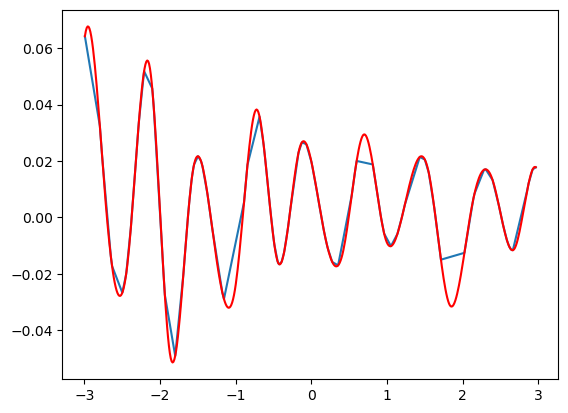

In [6]:
i = 5
plt.plot(x_data[x_data_order], X[x_data_order, i])
x_plot = np.linspace(np.min(x_data), np.max(x_data), 500)
plt.plot(x_plot, X_plot[:, i], color='red')
plt.show()

In [50]:
idata = az.from_netcdf("idata/idata_f3_0.33_svd_True_0.nc")

In [51]:
w_post = idata.posterior["w"].values.reshape(-1, X.shape[1])

In [52]:
B_post = X @ w_post.T
B_plot_post = X_plot @ w_post.T

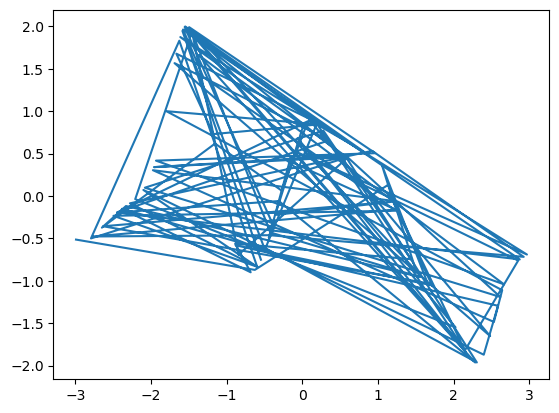

In [54]:
plt.plot(x_data[:], B_post.mean(axis=1)[:])

In [14]:
model_dict = {}
idata_dict = {}
model_keys = []
for f, sigma in [('f3', 0.33)]:
    for replication in [0, 1]:#, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]:
        for implementation in ['standard', 'centring+dropping', 'conditioning', 'spectral', 'svd']:
            if implementation=='spectral':
                model_keys.append((f, sigma, implementation, True, replication))
            else:
                for penalised in [True, False]:
                    model_keys.append((f, sigma, implementation, penalised, replication))

In [15]:
a = 1
b = 0.0005
n_internal_knots = 20
spline_degree = 3
order = 2

n_tune = 2000
n_draws = 2000
n_chains = 4
n_cores = 4

In [ ]:
for model_key in model_keys:
    print(model_key)
    (f, sigma, implementation, penalised, replication) = model_key
    
    
    if os.path.exists(f"idata/idata_{model_key[0]}_{model_key[1]}_{model_key[2]}_{model_key[3]}_{model_key[4]}.nc"):
        idata = az.from_netcdf(f"idata/idata_{model_key[0]}_{model_key[1]}_{model_key[2]}_{model_key[3]}_{model_key[4]}.nc")
    else:
        model_data = data[(f, sigma)][replication]
        x_data = model_data[0]
        y_data = model_data[1]

        model, X, X_plot = build_model_MvN(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)
        model_dict[(f, sigma, implementation, penalised, replication)] = model
        with model: 
            idata = pm.sample(tune = n_tune,
                                    draws = n_draws,
                                    chains = n_chains,
                                    random_seed=42,
                                    cores = n_cores,
                                    discard_tuned_samples=True,
                                    progressbar=True)
            idata.to_netcdf(f"idata/idata_{model_key[0]}_{model_key[1]}_{model_key[2]}_{model_key[3]}_{model_key[4]}.nc")
        idata_dict[model_key] = idata
    
    row = pd.DataFrame([{
        "key1": model_key[0],
        "key2": model_key[1],
        "key3": model_key[2],
        "key4": model_key[3],
        "key5": model_key[4],
        "runtime_seconds": idata.sample_stats.attrs["sampling_time"],
    }])

    # append or create csv
    if os.path.exists('idata/timings.csv'):
        row.to_csv('idata/timings.csv', mode="a", header=False, index=False)
    else:
        row.to_csv('idata/timings.csv', index=False)

    

('f3', 0.33, 'standard', True, 0)
('f3', 0.33, 'standard', False, 0)
('f3', 0.33, 'centring+dropping', True, 0)
('f3', 0.33, 'centring+dropping', False, 0)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, sigma_2, tau, w]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 33 seconds.


('f3', 0.33, 'conditioning', True, 0)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, sigma_2, tau, tau_p, theta]


Output()

In [ ]:
w_post = idata.posterior["w"] 

w_centered = w_post - w_post.mean(dim="w_dim_0")  # adjust dim name if needed

idata.posterior["w_centered"] = w_centered

In [121]:
w_post = idata.posterior["w"]


Vp_da = xr.DataArray(
    Vp,
    dims=("new_dim", "w_dim")
)

idata.posterior["Vpw"] = xr.dot(
    Vp_da,
    w_post,
    dims="w_dim"
)

In [134]:
az.summary(idata, var_names=['sigma_2','tau_p','w'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_2,0.101,0.015,0.074,0.128,0.000,0.000,5093.0,2888.0,1.00
tau_p,41.016,23.217,6.189,81.772,0.790,0.828,857.0,1423.0,1.01
w[0],-2.306,0.130,-2.561,-2.068,0.002,0.002,5366.0,2907.0,1.00
w[1],-2.058,0.135,-2.315,-1.807,0.002,0.002,4435.0,2921.0,1.00
w[2],2.990,0.137,2.733,3.242,0.002,0.002,4923.0,2631.0,1.00
w[3],-0.921,0.151,-1.210,-0.640,0.002,0.002,4133.0,2218.0,1.00
w[4],-0.730,0.144,-0.998,-0.458,0.002,0.002,4033.0,2928.0,1.00
w[5],-0.814,0.140,-1.062,-0.547,0.002,0.002,4919.0,3290.0,1.00
w[6],1.139,0.157,0.835,1.424,0.003,0.002,3504.0,2938.0,1.00
w[7],0.762,0.137,0.514,1.028,0.002,0.002,3059.0,3143.0,1.00


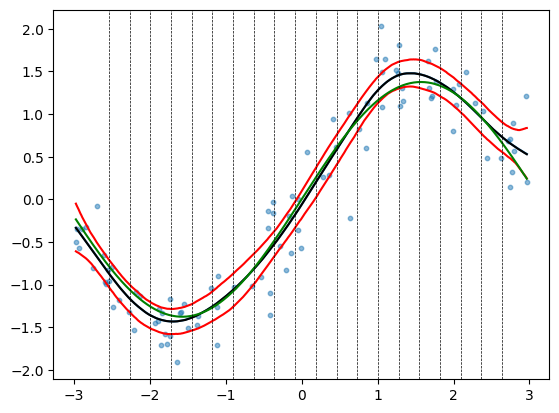

In [139]:
# svd
B_post = np.dot(B_plot - B_plot.mean(axis=0), Vp @ idata.posterior['w'].values.reshape(n_chains*n_draws, k-1).T)
B_post = B_post - np.mean(B_post, axis=0)
B_post_mean = B_post.mean(axis=1)
B_post_median = np.median(B_post, axis=1)
B_post_975 = np.percentile(B_post, 97.5, axis=1)
B_post_025 = np.percentile(B_post, 2.5, axis=1)

plt.plot(x_plot, B_post_mean)
plt.plot(x_plot, B_post_median, c='k')
plt.plot(x_plot, B_post_975, c='r')
plt.plot(x_plot, B_post_025, c='r')

f_evaluated = f3(x_plot)
f_evaluated /= np.std(f_evaluated)
plt.plot(x_plot, f_evaluated-f_evaluated.mean(), c='green')
plt.scatter(x_data, y_data, alpha=0.5, s=10)
for knot in interior_knots:
    plt.axvline(knot, c='k', ls='--', lw=0.5)
plt.show()

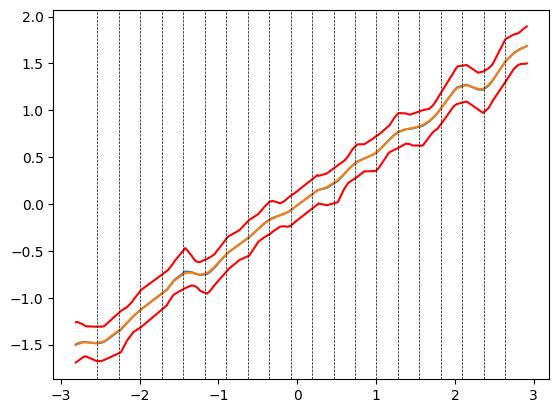

In [ ]:
# spectral
B_post = np.dot(Xp, idata.posterior['w'].values.reshape(n_chains*n_draws, r).T)
B_post = np.dot(X0, idata.posterior['w_trend'].values.reshape(n_chains*n_draws, order-1).T) + B_post
B_post = B_post - np.mean(B_post, axis=0)
B_post_mean = B_post.mean(axis=1)
B_post_median = np.median(B_post, axis=1)
B_post_975 = np.percentile(B_post, 97.5, axis=1)
B_post_025 = np.percentile(B_post, 2.5, axis=1)

plt.plot(x_data[x_data_order], B_post_mean[x_data_order])
plt.plot(x_data[x_data_order], B_post_median[x_data_order])
plt.plot(x_data[x_data_order], B_post_975[x_data_order], c='r')
plt.plot(x_data[x_data_order], B_post_025[x_data_order], c='r')
for knot in interior_knots:
    plt.axvline(knot, c='k', ls='--', lw=0.5)
plt.show()

In [ ]:
# k 
x_plot = np.linspace(np.min(x_data), np.max(x_data), 500)
eval_B_plot = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_plot)
B_plot = eval_B_plot['B'][:, :]
interior_knots = eval_B_plot['interior_knots']
B_post = np.dot(B_plot, idata.posterior['w'].values.reshape(n_chains*n_draws, k).T)
B_post = B_post - np.mean(B_post, axis=0)
B_post_mean = B_post.mean(axis=1)
B_post_median = np.median(B_post, axis=1)
B_post_975 = np.percentile(B_post, 97.5, axis=1)
B_post_025 = np.percentile(B_post, 2.5, axis=1)

In [ ]:
# k-1
x_plot = np.linspace(np.min(x_data), np.max(x_data), 500)
eval_B_plot = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x_data), np.max(x_data), n_internal_knots, x_plot)
B_plot = eval_B_plot['B'][:, :-1]
interior_knots = eval_B_plot['interior_knots']
B_post = np.dot(B_plot, idata.posterior['w'].values.reshape(n_chains*n_draws, k-1).T)
B_post = B_post - np.mean(B_post, axis=0)
B_post_mean = B_post.mean(axis=1)
B_post_median = np.median(B_post, axis=1)
B_post_975 = np.percentile(B_post, 97.5, axis=1)
B_post_025 = np.percentile(B_post, 2.5, axis=1)

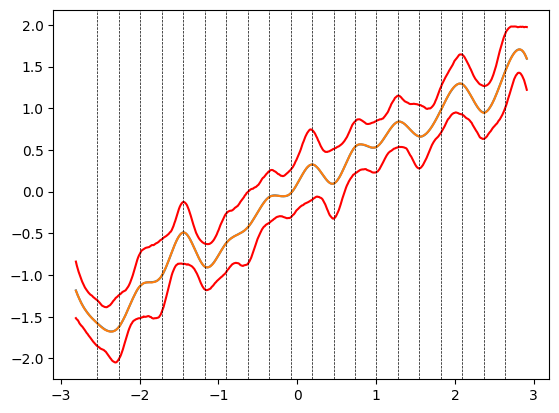

In [53]:
plt.plot(x_plot, B_post_mean[:])
plt.plot(x_plot, B_post_median[:])
plt.plot(x_plot, B_post_975[:], c='r')
plt.plot(x_plot, B_post_025[:], c='r')
for knot in interior_knots:
    plt.axvline(knot, c='k', ls='--', lw=0.5)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (100,) and (500,)

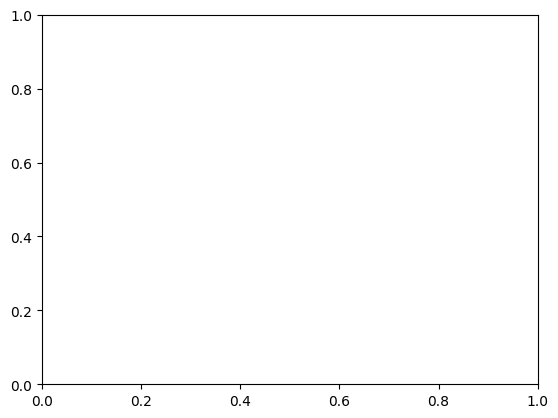

In [ ]:
plt.plot(x_data[x_data_order], B_post_mean[x_data_order])
plt.plot(x_data[x_data_order], B_post_median[x_data_order])
plt.plot(x_data[x_data_order], B_post_975[x_data_order], c='r')
plt.plot(x_data[x_data_order], B_post_025[x_data_order], c='r')
plt.show()